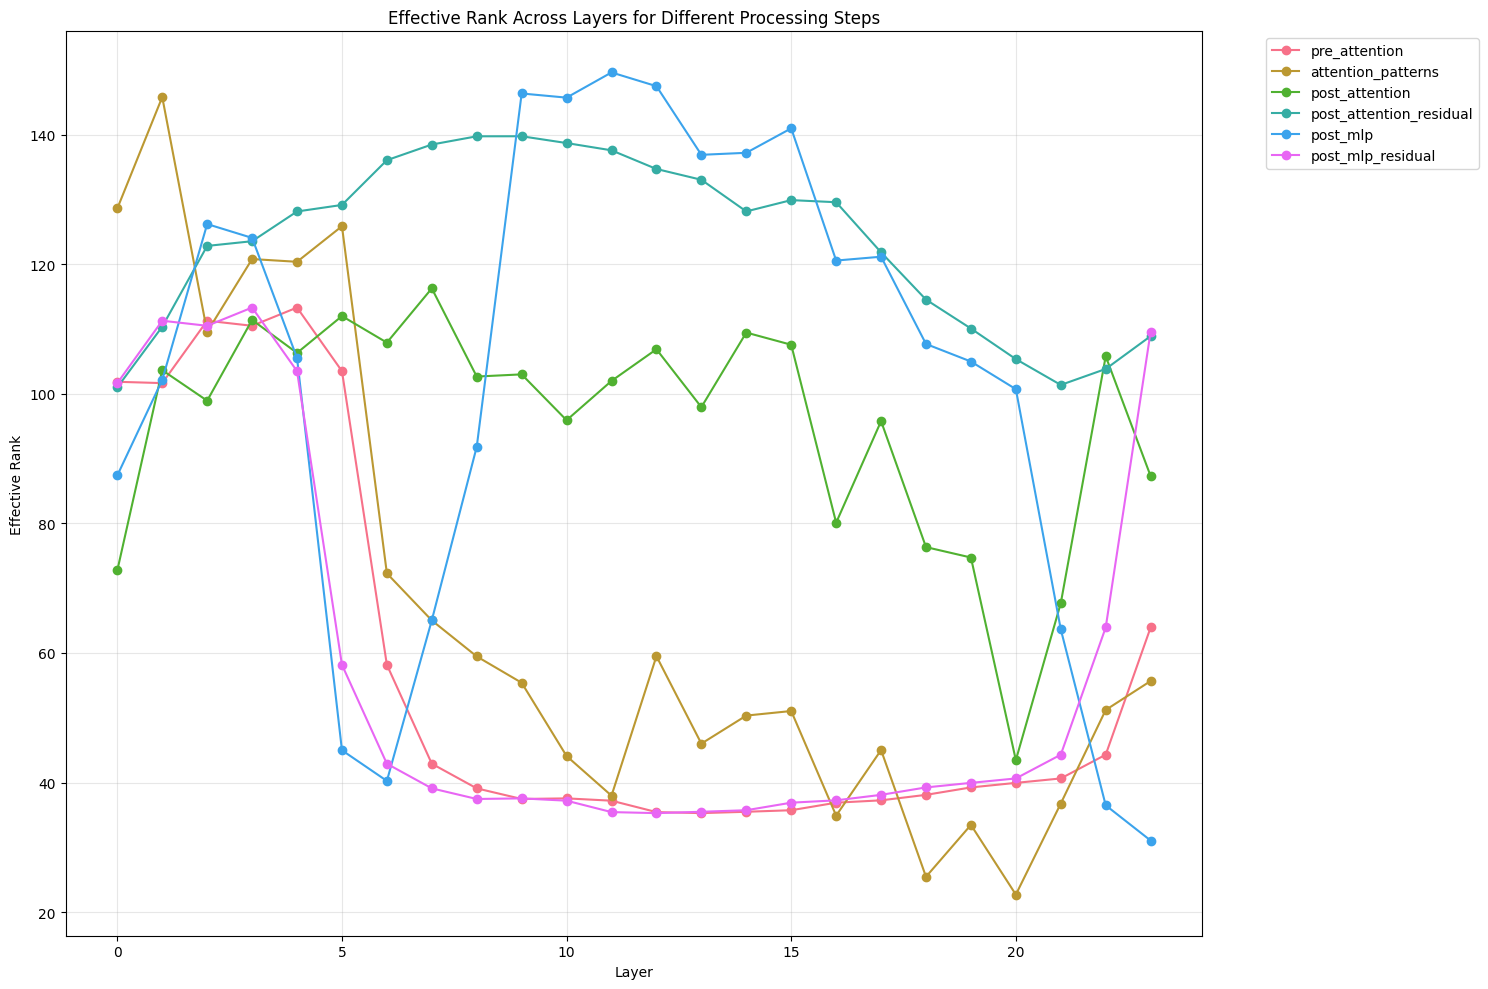

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import List, Dict

def calculate_effective_rank(singular_values: List[float]) -> float:
    """Calculate effective rank from singular values"""
    total = sum(singular_values)
    if total == 0:
        return 0
    normalized = [s/total for s in singular_values]
    entropy = -sum(p * np.log(p) for p in normalized if p > 0)
    return np.exp(entropy)

def analyze_ranks_from_json(json_path: str) -> tuple:
    """
    Analyze ranks from saved JSON results
    
    Args:
        json_path: Path to the JSON file containing analysis results
        
    Returns:
        tuple: (mean_ranks, std_ranks, num_layers)
    """
    # Load JSON data
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Get results
    results = data['results']
    
    step_names = [
        'pre_attention', 'attention_patterns', 'post_attention',
        'post_attention_residual', 'post_mlp', 'post_mlp_residual'
    ]
    
    # Dictionary to store ranks for each step and layer
    ranks = defaultdict(lambda: defaultdict(list))
    
    # Process results
    for model_size, batches in results.items():
        for batch in batches:
            for layer_stats in batch:
                layer_idx = layer_stats['layer']
                
                # Process each step
                for step_name in step_names:
                    stats = layer_stats[step_name]['stats']
                    
                    # For attention patterns, average across heads
                    if step_name == 'attention_patterns':
                        for head_stat in stats:
                            rank = calculate_effective_rank(head_stat['singular_values'])
                            ranks[step_name][layer_idx].append(rank)
                    else:
                        # For other steps, process each batch example
                        for stat in stats:
                            rank = calculate_effective_rank(stat['singular_values'])
                            ranks[step_name][layer_idx].append(rank)
    
    # Calculate means and standard deviations
    mean_ranks = defaultdict(list)
    std_ranks = defaultdict(list)
    
    # Get number of layers from the data
    num_layers = max(layer_idx for step in ranks.values() for layer_idx in step.keys()) + 1
    layers = range(num_layers)
    
    for step in step_names:
        for layer in layers:
            if layer in ranks[step]:
                mean_ranks[step].append(np.mean(ranks[step][layer]))
                std_ranks[step].append(np.std(ranks[step][layer]))
            else:
                mean_ranks[step].append(np.nan)
                std_ranks[step].append(np.nan)
    
    return mean_ranks, std_ranks, num_layers

def plot_ranks(mean_ranks: Dict[str, List[float]], num_layers: int, 
              output_path: str = None, fig_size: tuple = (15, 10)):
    """
    Create a plot of effective ranks across layers
    
    Args:
        mean_ranks: Dictionary of mean ranks for each step
        num_layers: Number of layers in the model
        output_path: Optional path to save the plot
        fig_size: Figure size as tuple (width, height)
    """
    plt.figure(figsize=fig_size)
    
    # Get step names and create color palette
    step_names = list(mean_ranks.keys())
    colors = sns.color_palette("husl", len(step_names))
    
    # Create plot
    layers = range(num_layers)
    for step, color in zip(step_names, colors):
        means = mean_ranks[step]
        plt.plot(layers, means, label=step, color=color, marker='o')
    
    plt.xlabel('Layer')
    plt.ylabel('Effective Rank')
    plt.title('Effective Rank Across Layers for Different Processing Steps')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
    
    plt.show()

def main(json_path: str, output_path: str = None):
    """
    Main function to process JSON and create visualization
    
    Args:
        json_path: Path to input JSON file
        output_path: Optional path to save the plot
    """
    # Analyze ranks from JSON
    mean_ranks, std_ranks, num_layers = analyze_ranks_from_json(json_path)
    
    # Create and save plot
    plot_ranks(mean_ranks, num_layers, output_path)

if __name__ == "__main__":
    # Example usage
    json_path = "/kaggle/input/pythia-output/analysis_results_only_singfsular/pythia_analysis_20250327_194501.json"
    output_path = "rank_analysis_plot_new.png"  # Optional
    main(json_path, output_path)